In [3]:
##Explorative Analyse der Großkorpora, um einen ausgewogenes Sample für die Analyse zu finden

In [1]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import pyphen
import spacy
import seaborn as sns
from typing import List, Dict, Any
from segmentizer import segment_dataframe

In [2]:
nlp = spacy.load("de_core_news_sm")

In [3]:
def read_txt_file(file_path):
    """
    Read a single txt file and return its content as a string.

    """
    with open(file_path, 'r', encoding='utf-8') as f:
        text = f.read()
    return text

<strong>Einlesen des Kafka-Korpus, explorative Analyse und Sampling</strong>
- Einlesen der Textdateien und Erstellung eines DataFrames
- Explorative Analyse der Teilkorpora anhand der Tokenanzahl
- Segmentierung der Texte in Segmente von ca. 1000 Tokens
- Sampling von 27 Segmente pro Teilkorpora

In [4]:
## Einlesen von Kafkas juristischen Texten
kafka_jur = []
kafka_jur_dir = 'data/kafka_jur'
for filename in os.listdir(kafka_jur_dir):
    if filename.endswith('.txt'):
        file_path = os.path.join(kafka_jur_dir, filename)
        text = read_txt_file(file_path)
        kafka_jur.append(text)

kafka_jur_df = pd.DataFrame({'text': kafka_jur})
kafka_jur_df.reset_index(inplace=True)
kafka_jur_df.rename(columns={'index': 'id'}, inplace=True)

kafka_jur_df["text"] = (
    kafka_jur_df["text"]
    .str.replace("\n", " ", regex=False)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

kafka_jur_df["corpus"] = "kafka_jur"

kafka_jur_df

,id,text,corpus
0,0,Umfang der Versicherungspflicht der Baugewerbe...,kafka_jur
1,1,8. „Die Mutterschaftsversicherung vom Standpun...,kafka_jur
2,2,"Kriegslage, Gefahrenklassen-Einreihung und Unf...",kafka_jur
3,3,Unfallverhütung und erste Hilfe A. Die Unfallv...,kafka_jur
4,4,Rede zur Amtseinsetzung des Direktors Diese Wa...,kafka_jur
5,5,Löblicher Vorstand! Der ergebenst Gefertigte e...,kafka_jur
6,6,Die Arbeiter-Versicherung und die Unternehmer ...,kafka_jur


In [5]:
## Einlesen von Kafkas Briefen an Felice Bauer
kafka_bauer = []
kafka_bauer_dir = 'data/kafka_briefe/Felice-Bauer'
for filename in os.listdir(kafka_bauer_dir):
    if filename.endswith('.txt'):
        file_path = os.path.join(kafka_bauer_dir, filename)
        text = read_txt_file(file_path)
        kafka_bauer.append(text)

kafka_bauer_df = pd.DataFrame({'text': kafka_bauer})
kafka_bauer_df.reset_index(inplace=True)
kafka_bauer_df.rename(columns={'index': 'id'}, inplace=True)

kafka_bauer_df["text"] = (
    kafka_bauer_df["text"]
    .str.replace("\n", " ", regex=False)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

kafka_bauer_df["corpus"] = "kafka_bauer"

kafka_bauer_df

,id,text,corpus
0,0,"Meine liebste Felice! Wie? Kopfschmerzen, schl...",kafka_bauer
1,1,Liebste Felice! Erst in dem letzten Brief erke...,kafka_bauer
2,2,"Der dritte Brief, den ich heute anfange. Immer...",kafka_bauer
3,3,Im Augenblick schlägt mir das Herz mit der Wut...,kafka_bauer
4,4,"Eben, Liebste, habe ich mir den Kopf zermarter...",kafka_bauer
...,...,...,...
311,311,Ich habe heute aus verschiedenen Gründen statt...,kafka_bauer
312,312,"Mein liebstes Kind, in meinem Roman gehn eben ...",kafka_bauer
313,313,"Das Wetter ist hier auch sehr schön, man nützt...",kafka_bauer
314,314,"Um die Wahrheit zu sagen, F.: in dem gestrigen...",kafka_bauer


In [6]:
## Einlesen von Kafkas Briefen an Maxc Brod
kafka_brod = []
kafka_brod_dir = 'data/kafka_briefe/Max-Brod'
for filename in os.listdir(kafka_brod_dir):
    if filename.endswith('.txt'):
        file_path = os.path.join(kafka_brod_dir, filename)
        text = read_txt_file(file_path)
        kafka_brod.append(text)

kafka_brod_df = pd.DataFrame({'text': kafka_brod})
kafka_brod_df.reset_index(inplace=True)
kafka_brod_df.rename(columns={'index': 'id'}, inplace=True)

kafka_brod_df["text"] = (
    kafka_brod_df["text"]
    .str.replace("\n", " ", regex=False)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

kafka_brod_df["corpus"] = "kafka_brod"

kafka_brod_df

,id,text,corpus
0,0,"Lieber Max, Ich danke dir. Sicher verzeihst Du...",kafka_brod
1,1,"Mein lieber Max Ich bin doch ganz unbrauchbar,...",kafka_brod
2,2,"Guten Morgen! Lieber Max, ich stand gestern be...",kafka_brod
3,3,Mein liebster Max! Nach langer Plage höre ich ...,kafka_brod
4,4,"12/2 1907 Lieber Max, ich schreibe Dir gerne, ...",kafka_brod
...,...,...,...
113,113,"Mein lieber Max, wer verlangt denn, dass Du mi...",kafka_brod
114,114,"Lieber Max, zur sofortigen Richtigstellung, ic...",kafka_brod
115,115,"Liebster Max, nicht weil es an und für sich un...",kafka_brod
116,116,"[den] 10. Juli [191] 1 Mein liebster Max, weil...",kafka_brod


In [ ]:
## Einlesen von Kafkas literarischen Texten
kafka_lit = []
kafka_lit_genre = []
kafka_lit_dir = 'data/kafka_korpus'
for root, dirs, files in os.walk(kafka_lit_dir):
    for filename in files:
        if filename.endswith(".txt"):
            file_path = os.path.join(root, filename)
            text = read_txt_file(file_path)

            kafka_lit.append(text)

            genre = os.path.basename(root)
            kafka_lit_genre.append(genre)

kafka_lit_df = pd.DataFrame({'text': kafka_lit, 'genre': kafka_lit_genre})
kafka_lit_df.reset_index(inplace=True)
kafka_lit_df.rename(columns={'index': 'id'}, inplace=True)

kafka_lit_df["text"] = (
    kafka_lit_df["text"]
    .str.replace("\n", " ", regex=False)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

## Verarbeitung der Texte für explorative Analyse der Genres
kafka_lit_df["doc"] = kafka_lit_df["text"].apply(nlp)
kafka_lit_df["tokens"] = kafka_lit_df["doc"].apply(lambda doc: [token.text for token in doc])
kafka_lit_df["token_count"] = kafka_lit_df["tokens"].apply(len)
kafka_lit_df["corpus"] = "kafka_lit"

kafka_lit_df

,id,text,genre,doc,tokens,token_count,corpus
0,0,Ich war in großer Verlegenheit: eine dringende...,erzählungen,"(Ich, war, in, großer, Verlegenheit, :, eine, ...","[Ich, war, in, großer, Verlegenheit, :, eine, ...",2608,kafka_lit
1,1,"I Als Eduard Raban, durch den Flurgang kommend...",erzählungen,"(I, Als, Eduard, Raban, ,, durch, den, Flurgan...","[I, Als, Eduard, Raban, ,, durch, den, Flurgan...",9958,kafka_lit
2,2,"Ein Philosoph trieb sich immer dort herum, wo ...",erzählungen,"(Ein, Philosoph, trieb, sich, immer, dort, her...","[Ein, Philosoph, trieb, sich, immer, dort, her...",244,kafka_lit
3,3,Gegen zwölf Uhr standen schon einige Leute auf...,erzählungen,"(Gegen, zwölf, Uhr, standen, schon, einige, Le...","[Gegen, zwölf, Uhr, standen, schon, einige, Le...",16905,kafka_lit
4,4,Wie sich mein Leben verändert hat und wie es s...,erzählungen,"(Wie, sich, mein, Leben, verändert, hat, und, ...","[Wie, sich, mein, Leben, verändert, hat, und, ...",16065,kafka_lit
...,...,...,...,...,...,...,...
59,59,"Es war ein Geier, der hackte in meine Füße. St...",erzählungen,"(Es, war, ein, Geier, ,, der, hackte, in, mein...","[Es, war, ein, Geier, ,, der, hackte, in, mein...",325,kafka_lit
60,60,"Kleines Arbeitszimmer, hohes Fenster, davor ei...",dramen,"(Kleines, Arbeitszimmer, ,, hohes, Fenster, ,,...","[Kleines, Arbeitszimmer, ,, hohes, Fenster, ,,...",5052,kafka_lit
61,61,"Jemand mußte Josef K. verleumdet haben, denn o...",roman_fragmente,"(Jemand, mußte, Josef, K., verleumdet, haben, ...","[Jemand, mußte, Josef, K., verleumdet, haben, ...",89897,kafka_lit
62,62,"Als der sechzehnjährige Karl Roßmann, der von ...",roman_fragmente,"(Als, der, sechzehnjährige, Karl, Roßmann, ,, ...","[Als, der, sechzehnjährige, Karl, Roßmann, ,, ...",100006,kafka_lit


In [12]:
kafka_lit_df.groupby("genre")["token_count"].agg([
    "count",
    "sum",
    "mean",
    "median",
    "min",
    "max"
])

,count,sum,mean,median,min,max
genre,,,,,,
erzählungen,60,180736,3012.266667,806.0,75,22297
roman_fragmente,3,282716,94238.666667,92813.0,89897,100006


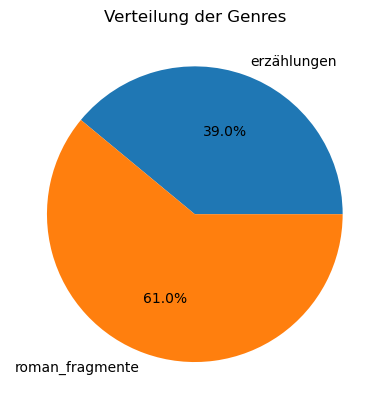

In [41]:
genre_counts = kafka_lit_df.groupby("genre")["token_count"].sum()

plt.figure()
genre_counts.plot(kind="pie", autopct="%1.1f%%")
plt.ylabel("")
plt.title("Verteilung der Genres")

plt.show()

In [13]:
kafka_lit_df[kafka_lit_df["genre"] == "roman_fragmente"].groupby("id")["token_count"].agg([
    "count",
    "sum",
])

,count,sum
id,,
61,1,89897
62,1,100006
63,1,92813


In [10]:
kafka_lit_df = kafka_lit_df[kafka_lit_df["genre"] != "dramen"]

In [11]:
kafka_korpus_df = pd.concat([kafka_jur_df, kafka_bauer_df, kafka_brod_df, kafka_lit_df], ignore_index=True)
kafka_korpus_df = kafka_korpus_df[kafka_korpus_df.token_count != 0]
kafka_korpus_df["id"] = kafka_korpus_df["corpus"] + "_" + kafka_korpus_df["id"].astype(str)
kafka_korpus_df["doc"] = kafka_korpus_df["text"].apply(nlp)
kafka_korpus_df["tokens"] = kafka_korpus_df["doc"].apply(lambda doc: [token.text for token in doc])
kafka_korpus_df["token_count"] = kafka_korpus_df["tokens"].apply(len)

kafka_korpus_df

,id,text,corpus,genre,doc,tokens,token_count
0,kafka_jur_0,Umfang der Versicherungspflicht der Baugewerbe...,kafka_jur,NaN,"(Umfang, der, Versicherungspflicht, der, Bauge...","[Umfang, der, Versicherungspflicht, der, Bauge...",10061
1,kafka_jur_1,8. „Die Mutterschaftsversicherung vom Standpun...,kafka_jur,NaN,"(8., „, Die, Mutterschaftsversicherung, vom, S...","[8., „, Die, Mutterschaftsversicherung, vom, S...",287
2,kafka_jur_2,"Kriegslage, Gefahrenklassen-Einreihung und Unf...",kafka_jur,NaN,"(Kriegslage, ,, Gefahrenklassen-Einreihung, un...","[Kriegslage, ,, Gefahrenklassen-Einreihung, un...",5352
3,kafka_jur_3,Unfallverhütung und erste Hilfe A. Die Unfallv...,kafka_jur,NaN,"(Unfallverhütung, und, erste, Hilfe, A., Die, ...","[Unfallverhütung, und, erste, Hilfe, A., Die, ...",5247
4,kafka_jur_4,Rede zur Amtseinsetzung des Direktors Diese Wa...,kafka_jur,NaN,"(Rede, zur, Amtseinsetzung, des, Direktors, Di...","[Rede, zur, Amtseinsetzung, des, Direktors, Di...",702
...,...,...,...,...,...,...,...
499,kafka_lit_58,Kinder auf der Landstraße Ich hörte die Wagen ...,kafka_lit,erzählungen,"(Kinder, auf, der, Landstraße, Ich, hörte, die...","[Kinder, auf, der, Landstraße, Ich, hörte, die...",7012
500,kafka_lit_59,"Es war ein Geier, der hackte in meine Füße. St...",kafka_lit,erzählungen,"(Es, war, ein, Geier, ,, der, hackte, in, mein...","[Es, war, ein, Geier, ,, der, hackte, in, mein...",325
501,kafka_lit_61,"Jemand mußte Josef K. verleumdet haben, denn o...",kafka_lit,roman_fragmente,"(Jemand, mußte, Josef, K., verleumdet, haben, ...","[Jemand, mußte, Josef, K., verleumdet, haben, ...",89897
502,kafka_lit_62,"Als der sechzehnjährige Karl Roßmann, der von ...",kafka_lit,roman_fragmente,"(Als, der, sechzehnjährige, Karl, Roßmann, ,, ...","[Als, der, sechzehnjährige, Karl, Roßmann, ,, ...",100006


In [14]:
kafka_korpus_df.groupby("corpus")["token_count"].agg([
    "count",
    "sum",
    "mean",
    "median",
    "min",
    "max"
])

,count,sum,mean,median,min,max
corpus,,,,,,
kafka_bauer,316,161237,510.243671,474.5,0,3354
kafka_brod,118,76655,649.618644,431.5,59,3180
kafka_jur,7,25432,3633.142857,3582.0,201,10061
kafka_lit,63,463452,7356.380952,901.0,75,100006


In [15]:
kafka_korpus_df.groupby("corpus")["token_count"].describe()

,count,mean,std,min,25%,50%,75%,max
corpus,,,,,,,,
kafka_bauer,316.0,510.243671,438.464841,0.0,232.25,474.5,621.25,3354.0
kafka_brod,118.0,649.618644,563.733023,59.0,222.00,431.5,918.50,3180.0
kafka_jur,7.0,3633.142857,3615.864186,201.0,494.50,3582.0,5299.50,10061.0
kafka_lit,63.0,7356.380952,20166.926683,75.0,351.00,901.0,3859.00,100006.0


<Axes: xlabel='corpus', ylabel='token_count'>

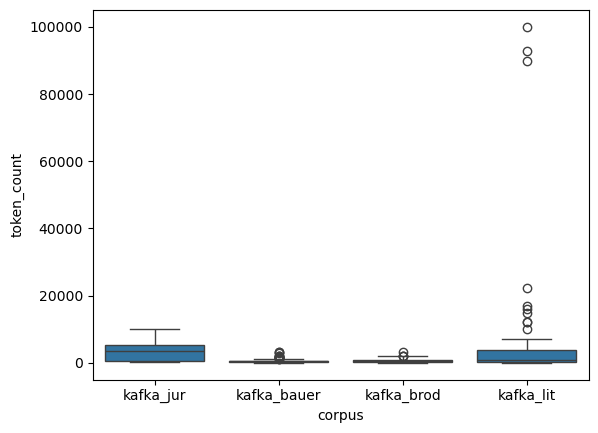

In [16]:
sns.boxplot(data=kafka_korpus_df, x="corpus", y="token_count")

In [116]:
## Segementierung der Texte in 1000-Token-Segmente

segments_df = segment_dataframe(
     kafka_korpus_df,
     text_col="text",
     id_col="id",
     corpus_col="corpus",
     genre_col="genre",
     target_tokens=1000,
     min_tokens=400,
)

segments_df.head(50)

,source_id,corpus,segment_id,segment_index,segment_text,token_count,sentence_count,genre
0,kafka_jur_0,kafka_jur,kafka_jur_0_1,1,Umfang der Versicherungspflicht der Baugewerbe...,970,31,NaN
1,kafka_jur_0,kafka_jur,kafka_jur_0_2,2,Schon in den beiden letzteren Entscheidungen w...,999,27,NaN
2,kafka_jur_0,kafka_jur,kafka_jur_0_3,3,Und zwei Monate später ergeht das Erkenntnis d...,989,32,NaN
3,kafka_jur_0,kafka_jur,kafka_jur_0_4,4,"Für die Betriebe, bei denen Werkstattarbeiten ...",974,29,NaN
4,kafka_jur_0,kafka_jur,kafka_jur_0_5,5,Hat dieser Umstand schon wiederholt zu Klagen ...,977,27,NaN
5,kafka_jur_0,kafka_jur,kafka_jur_0_6,6,"Auch die im Absatze 3, Zahl 2, und im Absatze ...",975,23,NaN
6,kafka_jur_0,kafka_jur,kafka_jur_0_7,7,«Bekanntlich hat der Verwaltungsgerichtshof mi...,961,22,NaN
7,kafka_jur_0,kafka_jur,kafka_jur_0_8,8,Neben den oben angeführten Gründen wurde die A...,960,30,NaN
8,kafka_jur_0,kafka_jur,kafka_jur_0_9,9,"Ein Unternehmer, der eine gedruckte Ablehnungs...",988,37,NaN
9,kafka_jur_0,kafka_jur,kafka_jur_0_10,10,Die Mehrzahl der Zustimmungserklärungen enthäl...,977,37,NaN


In [117]:
segments_df = segments_df[segments_df.token_count >= 300]
segments_df.groupby("corpus")["token_count"].describe()

,count,mean,std,min,25%,50%,75%,max
corpus,,,,,,,,
kafka_bauer,240.0,619.616667,219.011040,301.0,461.0,544.5,812.75,1000.0
kafka_brod,92.0,735.173913,249.434993,303.0,479.0,834.5,968.00,1000.0
kafka_jur,27.0,913.074074,172.255831,377.0,961.5,982.0,989.00,1000.0
kafka_lit,482.0,953.564315,115.495700,318.0,973.0,986.0,994.00,1000.0


In [ ]:
segments_df.groupby("corpus")["sentence_count"].describe()
segments_df.groupby("corpus").size()

corpus
kafka_bauer    240
kafka_brod      92
kafka_jur       27
kafka_lit      482
dtype: int64

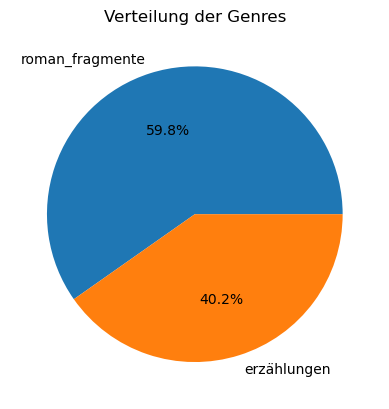

In [119]:
genre_counts = segments_df["genre"].value_counts()

plt.figure()
genre_counts.plot(kind="pie", autopct="%1.1f%%")
plt.ylabel("")
plt.title("Verteilung der Genres")

plt.show()

In [120]:
sample_size = 27
sampled_df = (
    segments_df
    .groupby("corpus")
    .sample(n=sample_size, weights="token_count", random_state=58)
)

sampled_df

,source_id,corpus,segment_id,segment_index,segment_text,token_count,sentence_count,genre
152,kafka_bauer_113,kafka_bauer,kafka_bauer_113_1,1,"Du, jetzt ist aber Eile nötig, wenn der Brief ...",461,23,NaN
189,kafka_bauer_149,kafka_bauer,kafka_bauer_149_1,1,"Ach Liebste, unendlich Geliebte, für meine kle...",975,34,NaN
218,kafka_bauer_178,kafka_bauer,kafka_bauer_178_1,1,"Meine liebste Felice, hat es einen Sinn (ich r...",515,21,NaN
57,kafka_bauer_27,kafka_bauer,kafka_bauer_27_1,1,Im Bureau. Es gibt viel zu tun. Böse war ich n...,371,27,NaN
247,kafka_bauer_202,kafka_bauer,kafka_bauer_202_1,1,"Liebe, liebste Felice, nicht das, nicht das. D...",576,29,NaN
...,...,...,...,...,...,...,...,...
937,kafka_lit_62,kafka_lit,kafka_lit_62_98,98,"Hier, die erste Kanzlei, ist, wie schon die Au...",995,45,roman_fragmente
600,kafka_lit_19,kafka_lit,kafka_lit_19_4,4,"War der große Haufe vorüber, dann kamen die Na...",993,38,erzählungen
825,kafka_lit_61,kafka_lit,kafka_lit_61_78,78,"Man hätte glauben können, der Advokat habe nic...",992,48,roman_fragmente
532,kafka_lit_1,kafka_lit,kafka_lit_1_3,3,"Man glaubt vielleicht, daß ich losstürze, wenn...",1000,49,erzählungen


In [121]:
sampled_df.groupby("corpus")["token_count"].describe()

,count,mean,std,min,25%,50%,75%,max
corpus,,,,,,,,
kafka_bauer,27.0,684.148148,219.729502,371.0,529.5,576.0,930.5,998.0
kafka_brod,27.0,803.259259,238.785161,310.0,714.0,917.0,966.5,994.0
kafka_jur,27.0,913.074074,172.255831,377.0,961.5,982.0,989.0,1000.0
kafka_lit,27.0,987.629630,14.652771,930.0,981.5,992.0,996.5,1000.0


In [ ]:
sampled_df.groupby("corpus")[["token_count"]].median()

token_count    91479
dtype: int64

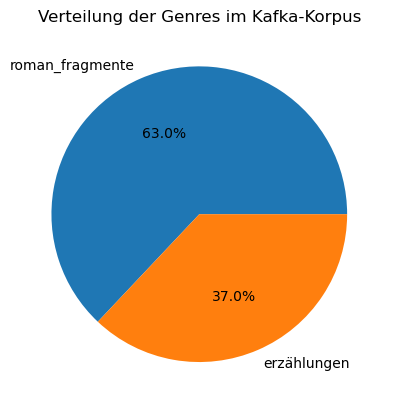

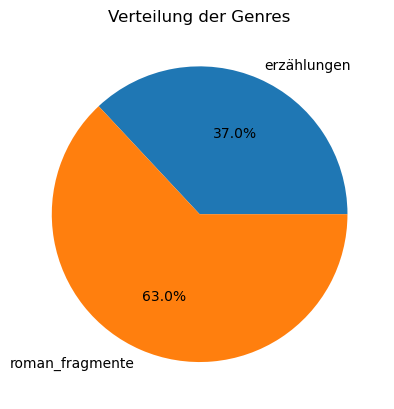

In [123]:
genre_counts = sampled_df["genre"].value_counts()

plt.figure()
genre_counts.plot(kind="pie", autopct="%1.1f%%")
plt.ylabel("")
plt.title("Verteilung der Genres im Kafka-Korpus")

plt.show()

genre_counts = sampled_df.groupby("genre")["token_count"].sum()

plt.figure()
genre_counts.plot(kind="pie", autopct="%1.1f%%")
plt.ylabel("")
plt.title("Verteilung der Genres")

plt.show()

<strong>Analyse des fertigen Korpus</strong>
- Verhältnis von Verben zu Substantiven und Nominalisierungen
- Vorgangspassivkonstruktionen
- Satzlänge und Satzkomplexität

<strong>Verhältnis von Verben zu Substantiven und Nominalisierungen</strong>

In [ ]:
def count_pos(doc):
    nouns = 0
    verbs = 0
    
    for token in doc:
        if token.pos_ == "NOUN":
            nouns += 1
        elif token.pos_ == "VERB":
            verbs += 1
            
    return nouns, verbs

In [125]:
sampled_df["doc"] = list(nlp.pipe(sampled_df["segment_text"]))
sampled_df[["nouns","verbs"]] = sampled_df["doc"].apply(
    lambda doc: count_pos(doc)
).apply(pd.Series)

In [126]:
sampled_df["noun_verb_ratio"] = sampled_df["nouns"] / sampled_df["verbs"]

In [127]:
blacklist_df = pd.read_csv("./aux/blacklist.csv")
blacklist_df.columns = ["word"]
blacklist = blacklist_df["word"].str.lower().tolist()
suffixes = ("ung", "heit", "keit", "tion", "schaft", "nis", "ität", "enz", "anz")
check_list = []

def count_contextual_nominalizations(doc):
    count = 0

    for token in doc:
        if token.pos_ != "NOUN":
            continue

        lemma = token.lemma_.lower()
        if not lemma.endswith(suffixes):
            continue
        if token.text.lower() in blacklist:
            continue

        prev_pos = doc[token.i - 1].pos_ if token.i > 0 else None
        next_pos = doc[token.i + 1].pos_ if token.i < len(doc) - 1 else None

        has_prep_or_det_before = prev_pos in {"ADP", "DET"}
        has_nominal_attachment_after = next_pos in {"ADP", "DET", "NOUN", "PROPN"}

        if has_prep_or_det_before or has_nominal_attachment_after:
            count += 1
            check_list.append(token.text)

    return count

sampled_df["nominalizations"] = sampled_df["doc"].apply(count_contextual_nominalizations)
sampled_df["nominalization_rate_percentage"] = ((sampled_df["nominalizations"] / sampled_df["token_count"]) * 100)

check_df = pd.DataFrame(check_list, columns=["nominalization"])
check_df.to_csv("./aux/nominalizations.csv", index=False)

In [173]:
sampled_df = sampled_df.rename(columns={"noun_verb_ratio": "abstraktionsgrad"})

In [174]:
sampled_df.groupby("corpus")[[
    "abstraktionsgrad",
    "nominalization_rate_percentage",
]].median()

,abstraktionsgrad,nominalization_rate_percentage
corpus,,
kafka_bauer,1.297872,0.733753
kafka_brod,1.500000,1.006036
kafka_jur,2.913043,4.518072
kafka_lit,1.138614,0.901804


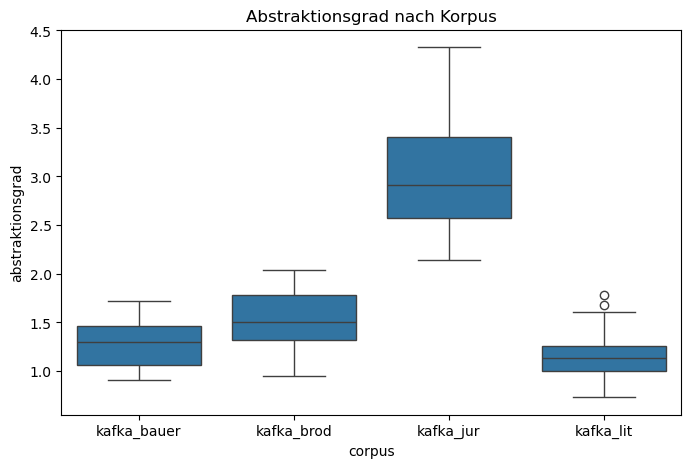

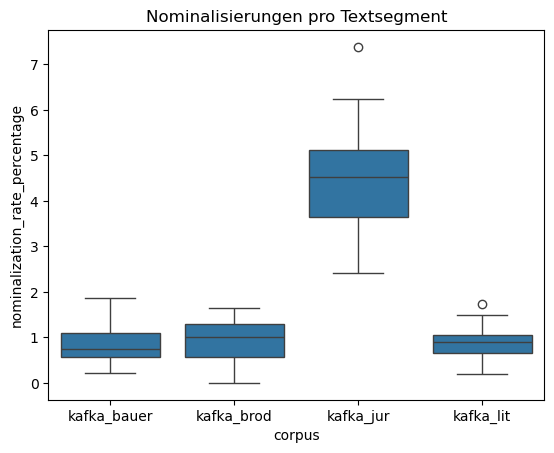

In [175]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=sampled_df,
    x="corpus",
    y="abstraktionsgrad"
)

plt.title("Abstraktionsgrad nach Korpus")
plt.show()

sns.boxplot(
    data=sampled_df,
    x="corpus",
    y="nominalization_rate_percentage",
)

plt.title("Nominalisierungen pro Textsegment")
plt.show()

In [ ]:
from scipy.stats import mannwhitneyu

jur = sampled_df[sampled_df["corpus"] == "kafka_jur"]
lit = sampled_df[sampled_df["corpus"] == "kafka_lit"]

nvr_test = mannwhitneyu(
    jur["abstraktionsgrad"],
    lit["abstraktionsgrad"],
    alternative="two-sided"
)

nom_test = mannwhitneyu(
    jur["nominalization_rate_percentage"],
    lit["nominalization_rate_percentage"],
    alternative="two-sided"
)

data = {
    "Merkmal": ["Abstraktionsgrad", "Nominalisierungsrate"],
    "U-Statistik": [nvr_test.statistic, nom_test.statistic],
    "p-Wert": [nvr_test.pvalue, nom_test.pvalue]
}

results_df = pd.DataFrame(data)

results_df = results_df.round(10)

print("Tabelle I: Ergebnisse des Mann-Whitney-U-Tests")
display(results_df)

Tabelle I: Ergebnisse des Mann-Whitney-U-Tests


,Merkmal,U-Statistik,p-Wert
0,Abstraktionsgrad,729.0,3.000000e-10
1,Nominalisierungsrate,729.0,3.000000e-10


<strong>Vorgangspassivkonstruktionen</strong>

In [ ]:
def count_passive(doc):
    passive_count = 0
    hits = []

    for token in doc:
        if token.lemma_ == "werden" and token.pos_ == "AUX":
            for child in token.children:
                if child.pos_ == "VERB" and "VerbForm=Part" in child.morph:
                    passive_count += 1
                    hits.append({
                        "satz": token.sent.text,
                        "werden": token.text,
                        "partizip": child.text
                    })
                    break

    return passive_count, hits


check_list = []

def apply_passive(row):
    count, hits = count_passive(row["doc"])
    for hit in hits:
        hit["doc_id"] = row.segment_id  
    check_list.extend(hits)
    return count

sampled_df["passive"] = sampled_df.apply(apply_passive, axis=1)
sampled_df["passive_rate_percentage"] = ((sampled_df["passive"] / sampled_df["token_count"]) * 100)

passive_df = pd.DataFrame(check_list, columns=["doc_id", "satz", "werden", "partizip"])
passive_df.to_csv("./aux/passive_hits.csv", index=False)

In [176]:
sampled_df.groupby("corpus")[[
    "passive_rate_percentage"
]].median()

,passive_rate_percentage
corpus,
kafka_bauer,0.183486
kafka_brod,0.201816
kafka_jur,1.025641
kafka_lit,0.201816


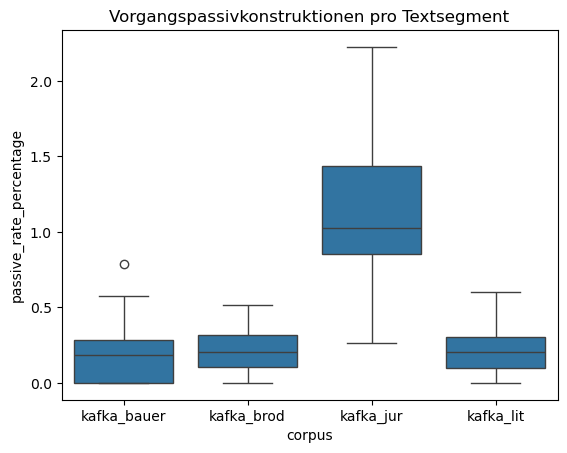

In [161]:
sns.boxplot(
    data=sampled_df,
    x="corpus",
    y="passive_rate_percentage",
)

plt.title("Vorgangspassivkonstruktionen pro Textsegment")
plt.show()

In [ ]:
jur = sampled_df[sampled_df["corpus"] == "kafka_jur"]
lit = sampled_df[sampled_df["corpus"] == "kafka_lit"]

prp_test = mannwhitneyu(
    jur["passive_rate_percentage"],
    lit["passive_rate_percentage"],
    alternative="two-sided"
)


data = {
    "Merkmal": ["Vorgangspassivrate"],
    "U-Statistik": [prp_test.statistic],
    "p-Wert": [prp_test.pvalue]}

results_df = pd.DataFrame(data)

results_df = results_df.round(10)

print("Tabelle I: Ergebnisse des Mann-Whitney-U-Tests")
display(results_df)

Tabelle I: Ergebnisse des Mann-Whitney-U-Tests


,Merkmal,U-Statistik,p-Wert
0,Vorgangspassivrate,711.0,2.100000e-09


<strong>Satzlänge und Satzkomplexität</strong>

In [154]:
def avg_sentence_length(doc):
    sentences = list(doc.sents)
    if not sentences:
        return 0
    token_counts = [len([t for t in sent if not t.is_punct and not t.is_space])for sent in sentences]

    return sum(token_counts) / len(token_counts)

sampled_df["avg_sentence_length"] = sampled_df["doc"].apply(avg_sentence_length)
sampled_df.groupby("corpus")[["avg_sentence_length"]].median()

,avg_sentence_length
corpus,
kafka_bauer,19.000000
kafka_brod,18.631579
kafka_jur,27.838710
kafka_lit,20.275000


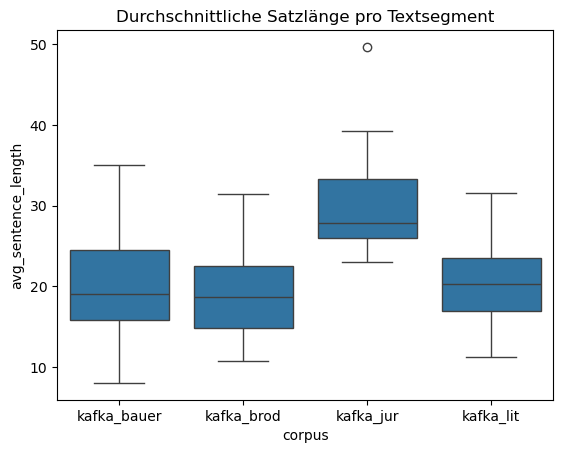

In [155]:
sns.boxplot(
    data=sampled_df,
    x="corpus",
    y="avg_sentence_length",
)

plt.title("Durchschnittliche Satzlänge pro Textsegment")
plt.show()

In [ ]:
jur = sampled_df[sampled_df["corpus"] == "kafka_jur"]
lit = sampled_df[sampled_df["corpus"] == "kafka_lit"]

sl_test = mannwhitneyu(
    jur["avg_sentence_length"],
    lit["avg_sentence_length"],
    alternative="two-sided"
)


data = {
    "Merkmal": ["Durchschnittliche Satzlänge"],
    "U-Statistik": [sl_test.statistic],
    "p-Wert": [sl_test.pvalue]}

results_df = pd.DataFrame(data)

results_df = results_df.round(10)

print("Tabelle I: Ergebnisse des Mann-Whitney-U-Tests")
display(results_df)

Tabelle I: Ergebnisse des Mann-Whitney-U-Tests


,Merkmal,U-Statistik,p-Wert
0,Durchschnittliche Satzlänge,646.5,0.000001


<strong>Korrelationsmatrix</strong>

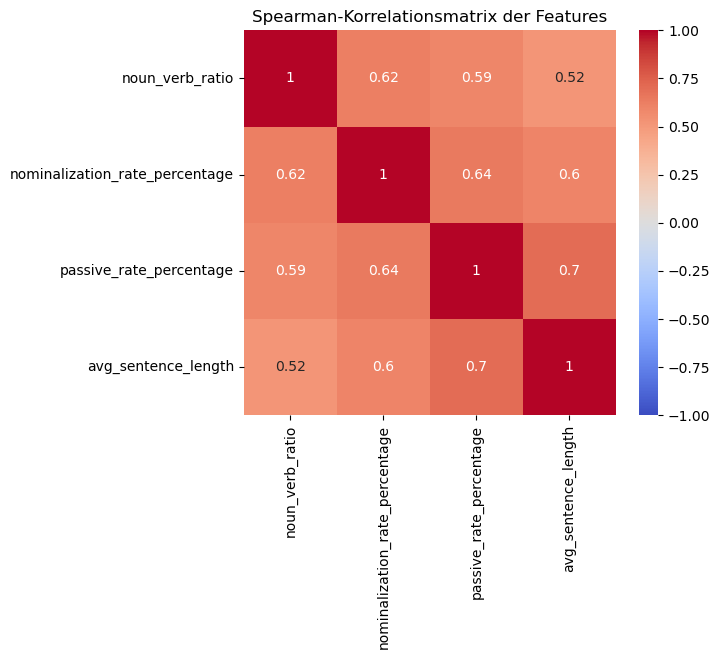

In [156]:
features = [
    "noun_verb_ratio",
    "nominalization_rate_percentage",
    "passive_rate_percentage",
    "avg_sentence_length"
]

feature_df = sampled_df[features]

correlation_matrix = feature_df.corr(method="spearman")

plt.figure(figsize=(6,5))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Spearman-Korrelationsmatrix der Features")
plt.show()